# Paper Pareto Figures: Low-Cost vs Commercial Synthetic Sensors

This notebook reproduces the paper-style synthetic post-processing figures from the legacy notebooks:

- `legacy/2.2-fcs_pareto.ipynb` -> `pareto.png`
- `legacy/4-comparison_between_settings.ipynb` -> `dcdt_comparison_violin_plots.png`

By default it reads processed synthetic `.nc` files from `/Users/alexnaokiasatokobayashi/Documents/FCS/processed_data_v4`. Edit `PROCESSED_DATA_DIR` below to use another folder.


## Setup


In [1]:
import pathlib
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import binned_statistic

warnings.filterwarnings("ignore")
sns.set_theme(style="ticks")

NOTEBOOK_DIR = pathlib.Path.cwd()
for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (candidate / "pyproject.toml").exists():
        PROJECT_ROOT = candidate
        break
else:
    PROJECT_ROOT = pathlib.Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from soilgasflux_fcs import pareto

POST_PROCESSING_DIR = PROJECT_ROOT / "notebooks" / "post_processing"
PROCESSED_DATA_DIR = pathlib.Path("/Users/alexnaokiasatokobayashi/Documents/FCS/processed_data_v4")
FIGURE_DIR = POST_PROCESSING_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CM = 1 / 2.54


## Configuration


In [2]:
NORMALIZATION_TYPE = "no"
ADD_INFO = "_test5"
DATE_LABEL = "2025-05-08"

TEST_NUMBERS = {
    "base": 5,
    "commercial": 6,
    "low-cost": 7,
}

INTENSITY_ORDER = ["low", "medium", "high"]
PARETO_CURVE_ORDER = ["straight", "big"]
VIOLIN_CURVE_ORDER = ["big", "straight"]
CURVE_NAMES = {"big": "convex", "straight": "linear"}

SENSOR_LABELS = {"low-cost": "Low-cost", "commercial": "Commercial"}
SENSOR_ORDER = ["low-cost", "commercial"]
COLORS = {"low-cost": sns.color_palette("coolwarm", n_colors=2)[0],
          "commercial": sns.color_palette("coolwarm", n_colors=2)[1]}

PARETO_PATH = FIGURE_DIR / "pareto.png"
VIOLIN_PATH = FIGURE_DIR / "dcdt_comparison_violin_plots.png"


## Load Processed Synthetic Outputs


In [3]:
def regular_filename(test_number):
    return f"test{test_number:02}_{NORMALIZATION_TYPE}Norm{ADD_INFO}_{DATE_LABEL}.nc"


def mcmc_filename(test_number):
    return f"test{test_number:02}_MC_{NORMALIZATION_TYPE}Norm{ADD_INFO}_{DATE_LABEL}.nc"


def expected_filename(test_number):
    return f"expected_test{test_number:02}_{DATE_LABEL}.nc"


def open_required(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing required processed file: {path}")
    return xr.open_dataset(path)


def assign_intensity_categories(expected_ds):
    dcdt = expected_ds["dcdt(HM)"]
    if "cutoff" in dcdt.dims:
        dcdt = dcdt.isel(cutoff=0)
    if "deadband" in dcdt.dims:
        dcdt = dcdt.isel(deadband=0)
    values = dcdt.values
    bin_indices = binned_statistic(values, values, bins=3)[2] - 1
    bin_indices = np.clip(bin_indices, 0, len(INTENSITY_ORDER) - 1)
    categories = np.array(INTENSITY_ORDER)[bin_indices]
    return expected_ds.assign_coords(
        intensity_categories=xr.DataArray(
            categories,
            coords={"time": expected_ds["time"]},
            dims=["time"],
        )
    )


def load_processed_data():
    data = {
        "regular": {},
        "mcmc": {},
        "expected": {},
    }
    for key, test_number in TEST_NUMBERS.items():
        data["regular"][key] = open_required(PROCESSED_DATA_DIR / regular_filename(test_number))
        data["mcmc"][key] = open_required(PROCESSED_DATA_DIR / mcmc_filename(test_number))
        data["expected"][key] = assign_intensity_categories(
            open_required(PROCESSED_DATA_DIR / expected_filename(test_number))
        )
    return data


data = load_processed_data()
ds_base = data["regular"]["base"]
dsMC_low = data["mcmc"]["low-cost"]
dsMC_com = data["mcmc"]["commercial"]
expected_ds = data["expected"]["low-cost"]

print("Loaded processed synthetic outputs from:", PROCESSED_DATA_DIR)
print("Low-cost:", dict(dsMC_low.sizes))
print("Commercial:", dict(dsMC_com.sizes))
print("Base:", dict(ds_base.sizes))


Loaded processed synthetic outputs from: /Users/alexnaokiasatokobayashi/Documents/FCS/processed_data_v4
Low-cost: {'time': 30, 'cutoff': 12, 'deadband': 6, 'MC': 15000}
Commercial: {'time': 30, 'cutoff': 12, 'deadband': 6, 'MC': 15000}
Base: {'time': 30, 'cutoff': 12, 'deadband': 6}


## Pareto Helpers


In [4]:
def select_group_times(expected, intensity, curve):
    return expected.where(
        (expected["intensity_categories"] == intensity)
        & (expected["curvature"] == curve),
        drop=True,
    )["time"].values


def pareto_result(dsMC, time_selection):
    pa = pareto.Pareto(dsMC=dsMC.sel(time=time_selection).median(dim=["time"]))
    norm_u, norm_l, flat_u, flat_l = pa.prepare_metrics()
    pareto_indices = pa.find_pareto_front(
        x=flat_u,
        y=flat_l,
        maximize_x=False,
        maximize_y=False,
    )
    coords = pa.get_coords_pareto(pareto_indices=pareto_indices)
    best_x, best_y = pa.get_best_from_pareto(
        pareto_indices=pareto_indices,
        metric_x=norm_u,
        metric_y=norm_l,
    )
    cutoff_coords = dsMC.coords["cutoff"]
    deadband_coords = dsMC.coords["deadband"]
    raw_uncertainty = pa.uncertaintyRange.values
    raw_logprob = pa.logprob.values
    return {
        "uncertainty": raw_uncertainty,
        "logprob": raw_logprob,
        "pareto_uncertainty": raw_uncertainty[coords],
        "pareto_logprob": raw_logprob[coords],
        "best_uncertainty": raw_uncertainty[best_x, best_y],
        "best_logprob": raw_logprob[best_x, best_y],
        "best_x": best_x,
        "best_y": best_y,
        "best_cutoff": cutoff_coords[best_x].item(),
        "best_deadband": deadband_coords[best_y].item(),
    }


def build_pareto_data(processed_data):
    result = {"commercial": {}, "low-cost": {}}
    for sensor in ["commercial", "low-cost"]:
        expected = processed_data["expected"][sensor]
        dsMC = processed_data["mcmc"][sensor]
        for intensity in INTENSITY_ORDER:
            for curve in PARETO_CURVE_ORDER:
                time_selection = select_group_times(expected, intensity, curve)
                if len(time_selection) == 0:
                    continue
                result[sensor][f"{intensity}_{curve}"] = pareto_result(dsMC, time_selection)
    return result


## Figure 1: Pareto Front Comparison


In [5]:
def plot_pareto_comparison(pareto_data):
    fig, axes = plt.subplots(2, 3, figsize=(19 * CM, 12 * CM), sharey=True, dpi=300)

    for row, curve in enumerate(PARETO_CURVE_ORDER):
        for col, intensity in enumerate(INTENSITY_ORDER):
            ax = axes[row, col]
            key = f"{intensity}_{curve}"
            for sensor in ["commercial", "low-cost"]:
                if key not in pareto_data[sensor]:
                    continue
                result = pareto_data[sensor][key]
                ax.scatter(
                    result["uncertainty"].ravel(),
                    result["logprob"].ravel(),
                    s=3,
                    c=[COLORS[sensor]],
                    alpha=0.3,
                )
                ax.scatter(
                    result["pareto_uncertainty"],
                    result["pareto_logprob"],
                    s=15,
                    c=[COLORS[sensor]],
                    alpha=0.8,
                    marker="o",
                    edgecolors="k",
                    linewidth=0.5,
                    zorder=5,
                )
                ax.scatter(
                    result["best_uncertainty"],
                    result["best_logprob"],
                    s=80,
                    c=[COLORS[sensor]],
                    alpha=0.9,
                    marker="*",
                    edgecolors="k",
                    linewidth=1,
                    zorder=10,
                )

            ax.set_xlim((0, 0.043))
            ax.set_ylim((-10, 200))
            ax.set_title(
                f"Curve type: {CURVE_NAMES[curve]}\nFlux intesity: {intensity}",
                fontsize=12,
            )
            if row == 1:
                ax.set_xlabel("Uncertainty Range", fontsize=11)
            if col == 0:
                ax.set_ylabel("Log Probability", fontsize=11)

            for sensor in ["low-cost", "commercial"]:
                if key not in pareto_data[sensor]:
                    continue
                result = pareto_data[sensor][key]
                x_best = result["best_uncertainty"]
                y_best = result["best_logprob"]
                x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
                y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
                if sensor == "commercial":
                    x_offset = x_range * 0.35
                    y_offset = y_range * 0.05
                else:
                    x_offset = x_range * 0.30
                    y_offset = y_range * 0.25
                ax.annotate(
                    f"CO: {result['best_cutoff']:.0f}\nDB: {result['best_deadband']:.0f}",
                    xy=(x_best, y_best),
                    xytext=(x_best + x_offset, y_best + y_offset),
                    fontsize=7,
                    ha="center",
                    va="center",
                    bbox=dict(
                        boxstyle="round,pad=0.2",
                        facecolor=COLORS[sensor],
                        alpha=0.2,
                        edgecolor=COLORS[sensor],
                    ),
                    arrowprops=dict(
                        arrowstyle="->",
                        connectionstyle="arc3,rad=0.1",
                        color="grey",
                        lw=1,
                    ),
                    zorder=15,
                )

    legend_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS["commercial"], markersize=6, alpha=0.6, label="Commercial setting"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS["low-cost"], markersize=6, alpha=0.6, label="Low-cost setting"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="none", markersize=6, markeredgecolor="k", linewidth=0.5, label="Pareto front"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="none", markersize=10, markeredgecolor="k", linewidth=1, label="$d_{min}$"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(0.35, -0.02),
        fontsize=9,
        title_fontsize=10,
        ncols=2,
    )
    fig.tight_layout()
    return fig


## Violin Helpers


In [6]:
FIXED_CONFIGS = [
    {"deadband": 0, "cutoff": 60, "marker": "s", "label": "Arbitrary 1", "color": "black"},
    {"deadband": 20, "cutoff": 80, "marker": "^", "label": "Arbitrary 2", "color": "green"},
    {"deadband": 20, "cutoff": 170, "marker": "o", "label": "Arbitrary 3", "color": "orange"},
]


def violin_group_dataframe(dsMC_low, dsMC_com, time_selection):
    rows = []
    for sensor, dsMC in [("low-cost", dsMC_low), ("commercial", dsMC_com)]:
        result = pareto_result(dsMC, time_selection)
        hist_dcdt = dsMC.sel(
            time=time_selection,
            deadband=result["best_deadband"],
            cutoff=result["best_cutoff"],
        )["dcdt(HM)"]
        values = hist_dcdt.median(dim="time").values.ravel()
        for value in values:
            rows.append(
                {
                    "dcdt(HM)": value,
                    "Dataset": SENSOR_LABELS[sensor],
                    "sensor": sensor,
                    "Deadband": result["best_deadband"],
                    "Cutoff": result["best_cutoff"],
                }
            )
    return pd.DataFrame(rows)


def fixed_config_value(dsMC, time_selection, deadband, cutoff):
    return dsMC.sel(time=time_selection, deadband=deadband, cutoff=cutoff)["dcdt(HM)"].median().item()


## Figure 2: dC/dt Comparison Split Violins


In [7]:
def plot_dcdt_comparison_violins(processed_data):
    dsMC_low = processed_data["mcmc"]["low-cost"]
    dsMC_com = processed_data["mcmc"]["commercial"]
    ds_base = processed_data["regular"]["base"]
    expected = processed_data["expected"]["low-cost"]
    color_list = [COLORS["low-cost"], COLORS["commercial"]]
    y_ranges = [(0.075, 0.115), (0.45, 0.55), (0.85, 1.15)]

    fig, axes = plt.subplots(2, 3, figsize=(19 * CM, 12.5 * CM), dpi=300)

    for row, curve in enumerate(VIOLIN_CURVE_ORDER):
        for col, intensity in enumerate(INTENSITY_ORDER):
            ax = axes[row, col]
            time_selection = select_group_times(expected, intensity, curve)
            df_violin = violin_group_dataframe(dsMC_low, dsMC_com, time_selection)

            ax.axhline(
                ds_base.sel(time=time_selection, deadband=0, cutoff=60)["dcdt(HM)"].median().item(),
                label="Base",
                color="black",
                linewidth=2,
            )
            ax.set_title(
                f"Curve type: {CURVE_NAMES[curve]}\nFlux intensity: {intensity}",
                fontsize=10,
            )

            sns.violinplot(
                data=df_violin,
                hue="Dataset",
                y="dcdt(HM)",
                split=True,
                palette=color_list,
                inner="quartiles",
                ax=ax,
                legend=False,
            )

            x_positions = [-0.3, 0.3]
            for i, sensor in enumerate(SENSOR_ORDER):
                dsMC = dsMC_low if sensor == "low-cost" else dsMC_com
                for config in FIXED_CONFIGS:
                    ax.scatter(
                        x_positions[i],
                        fixed_config_value(
                            dsMC,
                            time_selection,
                            config["deadband"],
                            config["cutoff"],
                        ),
                        marker=config["marker"],
                        s=30,
                        c=config["color"],
                        edgecolors="white",
                        linewidth=1,
                        alpha=0.7,
                        zorder=10,
                    )

            ax.set_ylim(y_ranges[col])
            ax.set_ylabel("$dCO_2/dt$" if col == 0 else "")
            ax.set_xlabel("")
            ax.set_xticks([])

            label_positions = [-0.25, 0.25]
            for i, sensor in enumerate(SENSOR_ORDER):
                dataset_data = df_violin[df_violin["sensor"] == sensor]
                if dataset_data.empty:
                    continue
                deadband = dataset_data["Deadband"].iloc[0]
                cutoff = dataset_data["Cutoff"].iloc[0]
                low, high = ax.get_ylim()
                ax.text(
                    label_positions[i],
                    high - (high - low) * 0.75,
                    f"DB:{deadband:.0f}\nCO:{cutoff:.0f}",
                    ha="center",
                    va="top",
                    fontsize=8,
                    bbox=dict(
                        boxstyle="round,pad=0.3",
                        facecolor=color_list[i],
                        alpha=0.8,
                    ),
                    zorder=10,
                )

    legend_elements = [
        Patch(facecolor=COLORS["low-cost"], label="Low-cost setting", alpha=1),
        Patch(facecolor=COLORS["commercial"], label="Commercial setting", alpha=1),
        Line2D([0], [0], color="black", linestyle="-", linewidth=1, label="Base (DB:0, CO:60)"),
    ]
    for config in FIXED_CONFIGS:
        legend_elements.append(
            Line2D(
                [0],
                [0],
                marker=config["marker"],
                color="w",
                markerfacecolor=config["color"],
                markersize=5,
                markeredgecolor="white",
                markeredgewidth=1,
                alpha=0.7,
                label=f"{config['label']} (DB:{config['deadband']}, CO:{config['cutoff']})",
            )
        )

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        fontsize=8,
        title_fontsize=8,
        ncols=3,
    )
    fig.tight_layout()
    return fig


## Generate And Export Figures


Saved Pareto comparison to: /Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/post_processing/figures/pareto.png
Saved dC/dt comparison violins to: /Users/alexnaokiasatokobayashi/git/soilgasflux_fcs/notebooks/post_processing/figures/dcdt_comparison_violin_plots.png


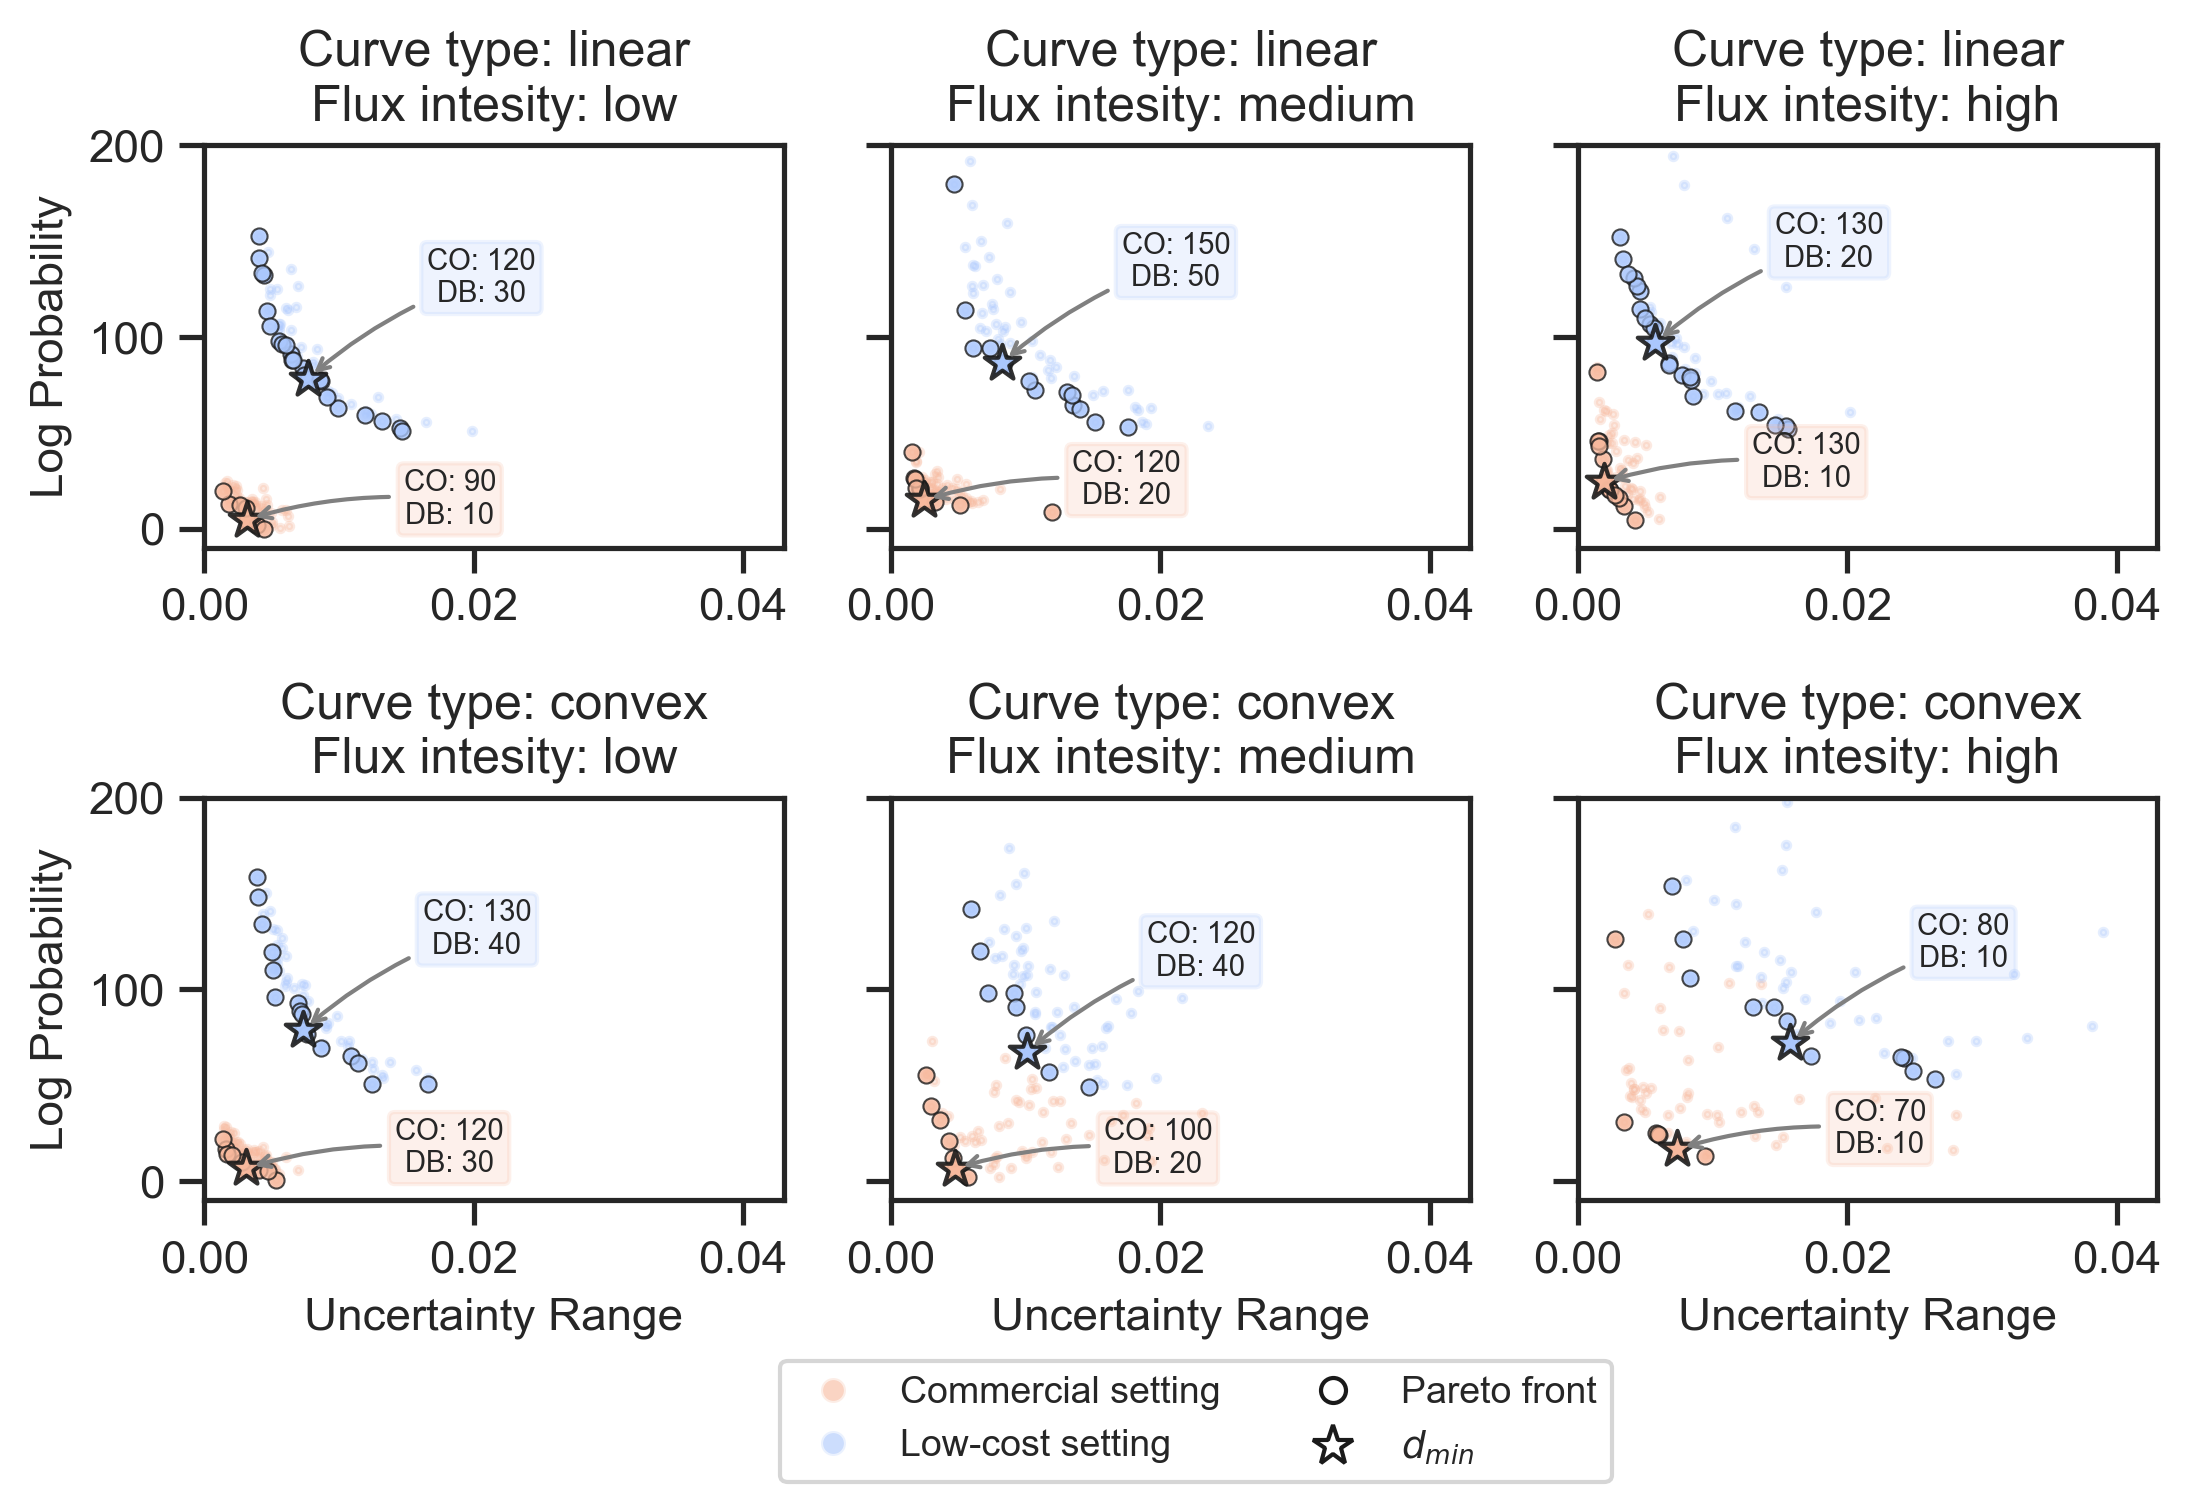

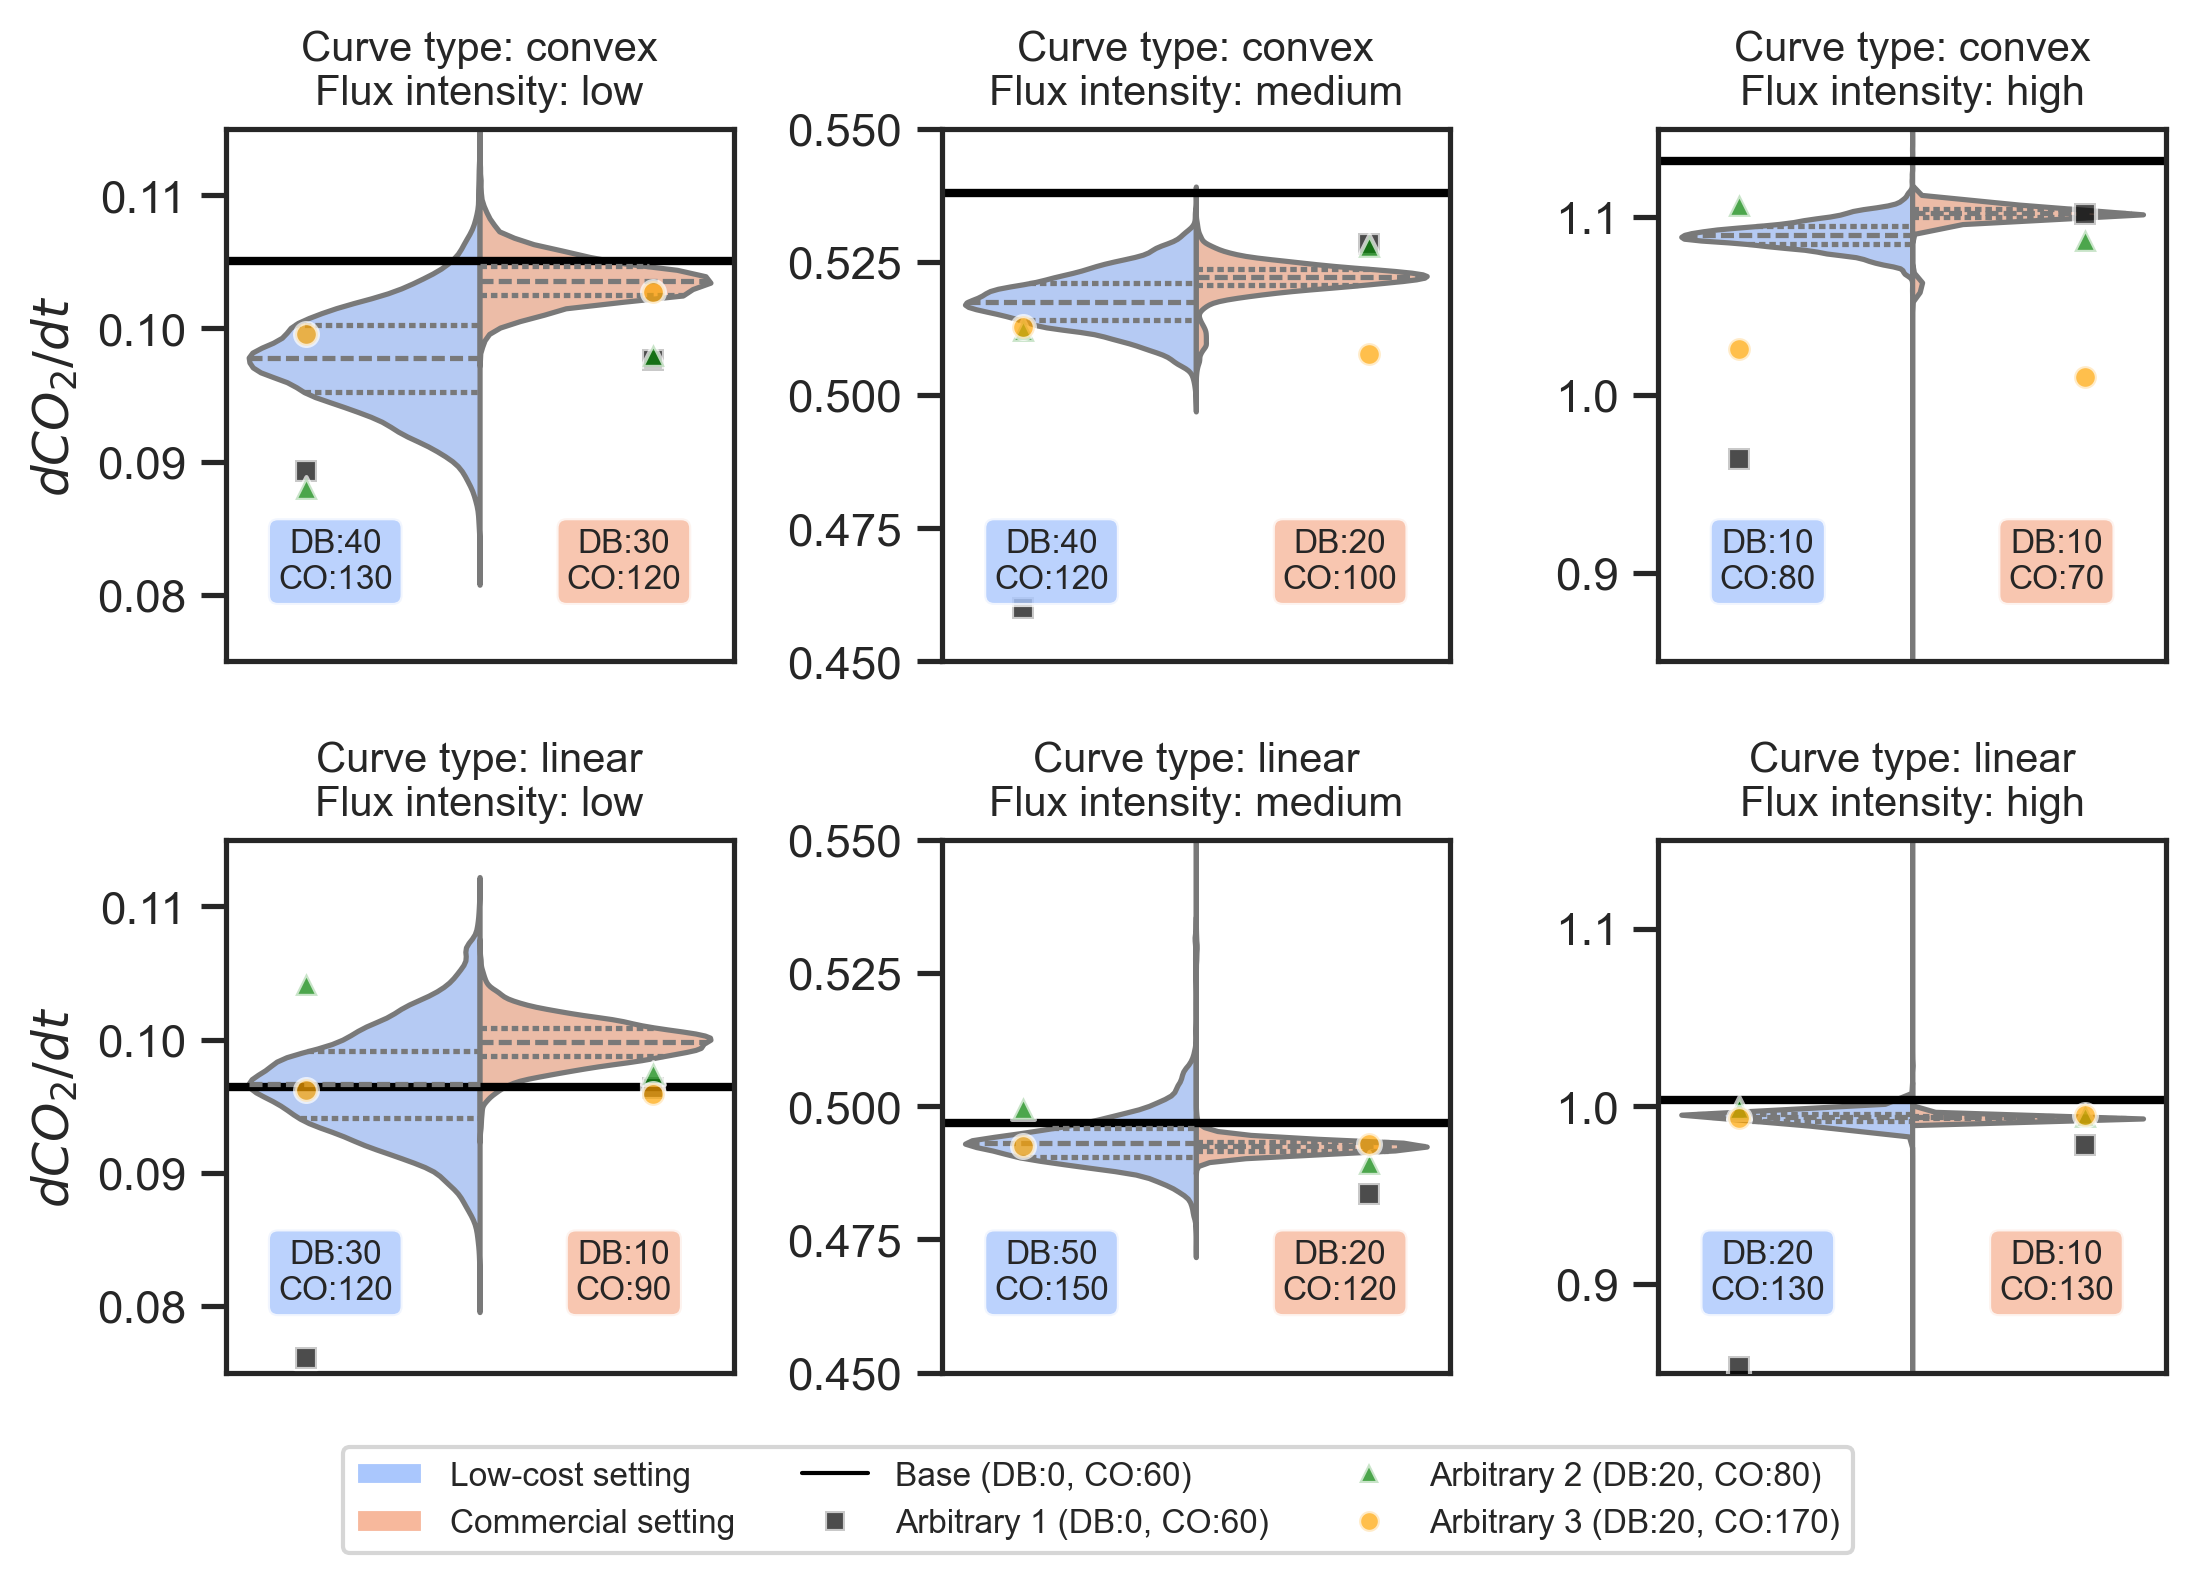

In [9]:
pareto_data = build_pareto_data(data)
pareto_fig = plot_pareto_comparison(pareto_data)
# pareto_fig.savefig(PARETO_PATH, dpi=300, bbox_inches="tight")

violin_fig = plot_dcdt_comparison_violins(data)
# violin_fig.savefig(VIOLIN_PATH, dpi=300, bbox_inches="tight")

print(f"Saved Pareto comparison to: {PARETO_PATH}")
print(f"Saved dC/dt comparison violins to: {VIOLIN_PATH}")
